In [1]:
import os
import time
import math
import torch
import torchvision
import numpy as np 
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.transforms import v2 
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms.v2 import MixUp, CutMix
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR, ReduceLROnPlateau

In [2]:
#defualt is highest
torch.set_float32_matmul_precision('high')

In [ ]:
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    batch_size: int = 256 
    warmup_epochs: int = 25
    epochs_count: int = 250  
    init_learning_rate: float = 1e-3  # initial learning rate for lr scheduler
    weight_decay: float = .1
    valid_interval: int = 1  
    data_root: str = "../datasets/" 
    num_workers: int = 8  
    device: str = 'cuda:1'  
    model_dir: str = 'models_vit_food101'
    log_dir: str = 'logs_vit_food101'
    model_name : str = 'vit_base_patch16_224'
    #model specific hyperparameters
    img_size: int = 224
    patch_size: int = 16
    dim: int = 512 #in paper it is 768 for base and 1024 for large
    heads: int = 8 #in paper it is 12 for base and 16 for large
    encoder_layers: int = 12 #in paper it is 12 for base and 24 for large
    dropout: float = 0.1


In [4]:
def train_transform():
    return v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomResizedCrop(224, scale=(0.6, 1.0), interpolation=v2.InterpolationMode.BICUBIC),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=20),
        v2.RandomGrayscale(p=0.1),
        v2.RandomAutocontrast(p=0.1),
        v2.RandAugment(num_ops=2, magnitude=15),  # stronger, no redundant ops
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225]),
        v2.RandomErasing(p=0.25),  
    ])

In [5]:
def valid_transform():
    return v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.Resize((224, 224)),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [6]:
dataset_train = torchvision.datasets.Food101(root='../datasets/', split='train', download=True, transform=train_transform())
dataset_test = torchvision.datasets.Food101(root='../datasets/', split='test', download=True, transform=valid_transform())

In [7]:
cutmix = CutMix(num_classes= len(dataset_train.classes), alpha=1.0)
mixup  = MixUp(num_classes=len(dataset_train.classes), alpha=0.2)

def apply_mixup_cutmix(images, labels):
    # randomly pick one per batch
    if torch.rand(1) < 0.5:
        return cutmix(images, labels)
    else:
        return mixup(images, labels)

In [8]:
len(dataset_train.classes)

101

In [9]:
len(dataset_test), len(dataset_train)

(25250, 75750)

In [10]:
def imagenet_denormalize(image):
    """Convert ImageNet-normalized image (H, W, C) back to [0,1] RGB."""
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    image = (image * std) + mean
    return np.clip(image, 0.0, 1.0)


In [11]:
img, label = dataset_train[1]
img = imagenet_denormalize(img.permute(1, 2, 0).numpy())

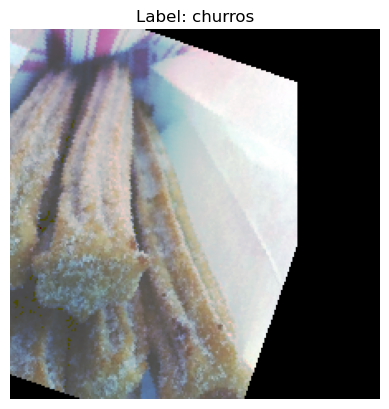

In [12]:
plt.imshow(img)
plt.axis('off')
plt.title(f'Label: {dataset_train.classes[label]}')
plt.show()

In [13]:
class FFN(nn.Module):
    
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
    def forward(self,x):
        return self.feed_forward(x)

In [14]:
class MultiHeadAttention(nn.Module):
    
    def __init__(self, d_model: int, h: int, dropout: float):
        super().__init__()
        self.d_model = d_model
        self.h = h
        
        assert d_model%h ==0, "d_model should be divisible by h"
        
        self.d_k = d_model//h
        self.w_q = nn.Linear(d_model,d_model, bias= False)
        self.w_k = nn.Linear(d_model,d_model, bias= False)        
        self.w_v = nn.Linear(d_model, d_model, bias= False)  
        
        self.w_o = nn.Linear(d_model, d_model, bias= False)  
        self.dropout = nn.Dropout(dropout)
        
    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        scores = query@key.transpose(-2,-1)/math.sqrt(d_k)
        #print(query.shape,key.shape, value.shape, scores.shape, mask.shape)
        if mask is not None:
            scores.masked_fill_(mask==0, -1e9)
        scores = scores.softmax(dim=-1)
        
        ### do we need ?
        if dropout is not None:
            scores = dropout(scores)
            
        return scores@value,scores 
        
    def forward(self, q, k, v, mask):
        # batch, seq len, embed dim
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)
        
        # batch, h, seq, d_k
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1,2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1,2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1,2)
        
        #x, scores = self.attention(query, key, value, mask, self.dropout)
        #using inbuilt flash attention
        x = F.scaled_dot_product_attention(query, key, value, attn_mask=mask, dropout_p=self.dropout.p)

        x = x.transpose(1,2).contiguous().view(x.shape[0], -1, self.h*self.d_k)
        
        return self.w_o(x)
        

In [15]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model:int, h:int, d_ff:int, dropout:float):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, h, dropout)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.layer_norm_1 = nn.LayerNorm(d_model)
        self.layer_norm_2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        x_ln = self.layer_norm_1(x)
        attention = self.attention(x_ln, x_ln, x_ln, mask)
        x = x + self.dropout(attention)
        
        ffn_out = self.ffn(self.layer_norm_2(x))
        x = x+ self.dropout(ffn_out)
        
        return x
        

In [16]:
class Transformer(nn.Module):
    def __init__(self,d_model:int, h:int, d_ff:int, dropout:float, N=6):
        super().__init__()
        
        self.encoder = nn.ModuleList(
            [
                EncoderBlock(d_model, h, d_ff, dropout)
                for _ in range(N)
            ]
        )
        
    
    def forward(self,x, mask=None):
        for layer in  self.encoder:
            x = layer(x, mask)
        return x
    

In [17]:
def img_to_patches(img, patch_size):
    bs, c, h, w = img.shape
    assert h % patch_size == 0 and w % patch_size == 0, "Image dimensions must be divisible by the patch size."
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size
    img = img.reshape(bs, c, num_patches_h, patch_size, num_patches_w, patch_size)
    img = img.permute(0, 2, 4, 1, 3, 5).contiguous()  # (batch_size, num_patches_h, num_patches_w, channels, patch_size, patch_size)
    patches = img.view(bs, num_patches_h * num_patches_w, c * patch_size * patch_size)  # (batch_size, num_patches, patch_dim)
    return patches


In [18]:
class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, num_classes=len(dataset_train.classes),
                  dim =512, heads=8, encoder_layers=12, dropout=0.1):
        super(ViT, self).__init__() 
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.linear_proj = nn.Linear(3*patch_size*patch_size, dim)
        self.transformer = Transformer(dim, heads, dim*4, dropout, encoder_layers)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.embedding = nn.Parameter(torch.randn(1, self.num_patches+1, dim))
        self.dropout = nn.Dropout(dropout)
        self.class_layer = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = img_to_patches(x, self.patch_size)  # (batch_size, num_patches, patch_dim)
        x = self.linear_proj(x)  # (batch_size, num_patches, dim)
        cls_token = self.cls_token.repeat(x.shape[0], 1, 1)  # (batch_size, 1, dim)
        x = torch.cat((cls_token, x), dim=1)  # (batch_size, num_patches + 1, patch_dim)
        x = x + self.embedding  # (batch_size, num_patches + 1, dim)
        x = self.dropout(x)
        x = self.transformer(x)  # (batch_size, num_patches + 1, dim)
        x = self.class_layer(x[:, 0])  # (batch_size, num_classes)
        return x

In [19]:
def initialize_weight(model: ViT):
    for name,p in model.named_parameters():
        if p.dim()>1:
            nn.init.xavier_uniform_(p)
        else:
            if 'layer' in name:
                continue
            else:
                nn.init.zeros_(p)

In [ ]:
def train(
    train_config: TrainingConfiguration, model: nn.Module, optimizer: torch.optim.Optimizer,
    train_loader: torch.utils.data.DataLoader, epoch_idx: int
) -> tuple[float, float]:
    
    # change model in training mood
    model.train()
    criterion = torch.nn.CrossEntropyLoss()
    # to get batch loss
    batch_loss = np.array([])
    
    # to get batch accuracy
    batch_acc = np.array([])
        
    for batch_idx, (data, target) in enumerate(train_loader):
        
        # clone target
        indx_target = target.clone()
        # send data to device (its is medatory if GPU has to be used)
        data = data.to(train_config.device)
        # send target to device
        target = target.to(train_config.device)
        
        data, target = apply_mixup_cutmix(data, target)  

        # reset parameters gradient to zero
        optimizer.zero_grad()
        
        with torch.autocast(device_type=train_config.device, dtype=torch.bfloat16):
            # forward pass to the model
            output = model(data)        
            # cross entropy loss
            loss = criterion(output, target)

        # find gradients w.r.t training parameters
        loss.backward()
        # Update parameters using gardients
        optimizer.step()
        
        batch_loss = np.append(batch_loss, [loss.item()])
        
        # Score to probability using softmax
        prob = F.softmax(output, dim=1)
            
        # get the index of the max probability
        pred = prob.data.max(dim=1)[1]  
                        
        # correct prediction
        correct = pred.cpu().eq(indx_target).sum().item()
            
        # accuracy
        acc = float(correct) / float(len(data))
        
        batch_acc = np.append(batch_acc, [acc])
            
    epoch_loss = batch_loss.mean()
    epoch_acc = batch_acc.mean()
    print('Epoch: {} \nTrain Loss: {:.6f} Acc: {:.4f}'.format(epoch_idx, epoch_loss, epoch_acc))
    return epoch_loss, epoch_acc

In [21]:
def validate(
    train_config: TrainingConfiguration,
    model: nn.Module,
    test_loader: torch.utils.data.DataLoader,
) -> tuple[float, float]:
    # 
    model.eval()
    test_loss = 0
    count_corect_predictions = 0
    with torch.no_grad():
        for data, target in test_loader:
            indx_target = target.clone()
            data = data.to(train_config.device)
            
            target = target.to(train_config.device)
            
            output = model(data)
            # add loss for each mini batch
            test_loss += F.cross_entropy(output, target).item()
            
            # Score to probability using softmax
            prob = F.softmax(output, dim=1)
            
            # get the index of the max probability
            pred = prob.data.max(dim=1)[1] 
            
            # add correct prediction count
            count_corect_predictions += pred.cpu().eq(indx_target).sum().numpy()

    # average over number of mini-batches
    test_loss = test_loss / len(test_loader)  
    
    # average over number of dataset
    accuracy = 100. * count_corect_predictions / len(test_loader.dataset)
    
    print(
        'Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, count_corect_predictions, len(test_loader.dataset), accuracy
        )
    )
    
    return test_loss, accuracy/100.0

In [22]:
def save_model(model, device, model_dir, model_file_name):
    

    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    model_path = os.path.join(model_dir, model_file_name)

    # make sure you transfer the model to cpu.
    if device == 'cuda':
        model.to('cpu')

    # save the state_dict
    torch.save(model.state_dict(), model_path)
    
    if device == 'cuda':
        model.to('cuda')
    
    return

In [23]:
def load_model(model, model_dir, model_file_name):
    model_path = os.path.join(model_dir, model_file_name)

    # loading the model and getting model parameters by using load_state_dict
    model.load_state_dict(torch.load(model_path))
    
    return model

In [24]:
def main(model,summary_writer,train_data,valid_data,optimizer,scheduler=None,\
         training_configuration=TrainingConfiguration()):
    
    train_loader = DataLoader(
        dataset=train_data, 
        batch_size=training_configuration.batch_size,
        num_workers=training_configuration.num_workers,
        shuffle=True
    )
    
    valid_loader = DataLoader(
        dataset=valid_data, 
        batch_size=training_configuration.batch_size,
        num_workers=training_configuration.num_workers
    )
    
    
    # send model to device (GPU/CPU)
    model.to(training_configuration.device)

    best_loss = torch.tensor(np.inf)
    best_acc = 0.0
    
    t_begin = time.time()
    for epoch in range(training_configuration.epochs_count):
        
        # Train and visualize training images
        train_loss, train_acc = train(training_configuration, model, optimizer, train_loader, epoch)
        summary_writer.add_scalar('Train Loss', train_loss, epoch)
        summary_writer.add_scalar('Train Accuracy', train_acc, epoch)
        
        # Validate
        if epoch % training_configuration.valid_interval == 0:
            valid_loss, valid_acc = validate(training_configuration, model, valid_loader)
            summary_writer.add_scalar('Validation Loss', valid_loss, epoch)
            summary_writer.add_scalar('Validation Accuracy', valid_acc, epoch)
            if valid_acc > best_acc:
                best_acc = valid_acc
                print('...Model Improved. Saving the Model...')
                save_model(model, device=training_configuration.device,
                           model_dir=training_configuration.model_dir,
                           model_file_name= training_configuration.model_name+'_best.pt')

            if valid_loss < best_loss:
                best_loss = valid_loss
                
        elapsed_time = time.time() - t_begin
        speed_epoch = elapsed_time / (epoch + 1)
        eta = speed_epoch *training_configuration.epochs_count - elapsed_time

        #writing scalers to tensorboard
        summary_writer.add_scalar('Learning Rate',optimizer.param_groups[0]['lr'] , epoch)
        summary_writer.add_scalar('Time Elapsed',elapsed_time, epoch)
        summary_writer.add_scalar('ETA',eta, epoch)
        
        if scheduler is not None:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(valid_acc)
            else:
                scheduler.step()
    
    print("Total time: {:.2f}, Best Accuracy: {:.3f}".format(time.time() - t_begin, best_acc))

In [25]:
train_config = TrainingConfiguration()

model = ViT(
    img_size=train_config.img_size,
    patch_size=train_config.patch_size,
    dim=train_config.dim,
    heads=train_config.heads,
    encoder_layers=train_config.encoder_layers,
    dropout=train_config.dropout
)
initialize_weight(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = train_config.init_learning_rate,
    weight_decay = train_config.weight_decay
)



In [ ]:
# Warms up from (1e-3 * 0.01) → 1e-3 over 25 epochs
warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.01,   # starts at 1% of base LR
    end_factor=1.0,      # ends at 100% of base LR
    total_iters=train_config.warmup_epochs
)

# Decays from 1e-3 → 1e-5 over remaining epochs
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max= train_config.epochs_count - train_config.warmup_epochs,
    eta_min=1e-5
)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[train_config.warmup_epochs]   # switch point
)

In [27]:
summary_writer = SummaryWriter(log_dir=train_config.log_dir)

In [28]:
model.to(train_config.device)
print('')

In [29]:
model = torch.compile(model)

In [30]:
main(model,summary_writer, dataset_train, dataset_test, optimizer,scheduler=scheduler)

W0413 06:51:19.839000 33618 site-packages/torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch: 0 
Train Loss: 6.423415 Acc: 0.0123
Test set: Average loss: 4.6165, Accuracy: 787/25250 (3.12%)

...Model Improved. Saving the Model...
Epoch: 1 
Train Loss: 5.655776 Acc: 0.0139
Test set: Average loss: 4.6759, Accuracy: 1126/25250 (4.46%)

...Model Improved. Saving the Model...
Epoch: 2 
Train Loss: 5.172826 Acc: 0.0172
Test set: Average loss: 4.4871, Accuracy: 1381/25250 (5.47%)

...Model Improved. Saving the Model...
Epoch: 3 
Train Loss: 4.923501 Acc: 0.0206
Test set: Average loss: 4.4172, Accuracy: 1522/25250 (6.03%)

...Model Improved. Saving the Model...
Epoch: 4 
Train Loss: 4.794401 Acc: 0.0242
Test set: Average loss: 4.2857, Accuracy: 1719/25250 (6.81%)

...Model Improved. Saving the Model...
Epoch: 5 
Train Loss: 4.684783 Acc: 0.0278
Test set: Average loss: 4.2367, Accuracy: 1737/25250 (6.88%)

...Model Improved. Saving the Model...
Epoch: 6 
Train Loss: 4.615063 Acc: 0.0314
Test set: Average loss: 4.0966, Accuracy: 2354/25250 (9.32%)

...Model Improved. Saving the Mo

In [31]:
model = load_model(model, train_config.model_dir, train_config.model_name+'_best.pt')

In [33]:
valid_loader = DataLoader(dataset_test, batch_size=train_config.batch_size, shuffle=False, num_workers=train_config.num_workers)

In [34]:
labels = []
preds = []
model.eval()
with torch.no_grad():
    for img, label in valid_loader:
        img = img.to(train_config.device)
        label = label.to(train_config.device)
        output = model(img)
        probs = F.softmax(output, dim=1)
        pred = probs.argmax(dim=1)
        labels.extend(label.cpu().numpy())
        preds.extend(pred.cpu().numpy())

In [35]:
labels = np.array(labels)
preds = np.array(preds)

In [36]:
class ConfusionMatrix:
    def __init__(self):
        # init confusion matrix
        self.conf = np.zeros((len(dataset_test.classes), len(dataset_test.classes)), np.int32)

    def reset(self):
        # reset to zero
        self.conf.fill(0)

    def add(self, pred, target):
        """
        This will take predicted probability and True label and compute confusion matrix
        """
        replace_indices = np.vstack((target.flatten(), pred.flatten())).T

        conf, _ = np.histogramdd(replace_indices, bins=(len(dataset_test.classes),
                        len(dataset_test.classes)), 
                        range=[(0, len(dataset_test.classes)), (0, len(dataset_test.classes))])

        self.conf += conf.astype(np.int32)
    
    def confusion_matrix(self):
      
        return self.conf.T

In [37]:
cm = ConfusionMatrix()

# reset confusion matrix
cm.reset()

# compute confusion matrix
cm.add(preds, labels)


#print('Confusion Matrix :\n{}'.format(cm.confusion_matrix()))


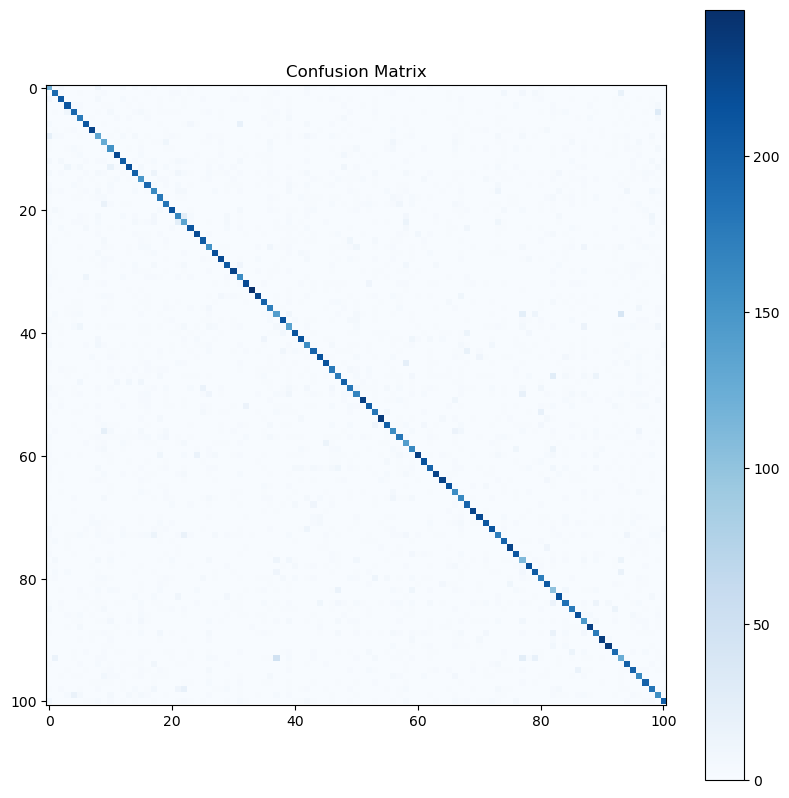

In [38]:
plt.figure(figsize = (10,10))
plt.imshow(cm.confusion_matrix(), interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(dataset_test.classes))
#plt.xticks(tick_marks, dataset_test.classes)
#plt.yticks(tick_marks, dataset_test.classes)
plt.show()


In [39]:
wrong_predictions = cm.confusion_matrix().sum(axis=0) - np.diag(cm.confusion_matrix())

In [40]:
most_wrongly_predicted_classes = wrong_predictions.argsort()[-5:][::-1]

In [41]:
for idx in most_wrongly_predicted_classes:
    print(f"Class: {dataset_test.classes[idx]}, Wrong Predictions: {wrong_predictions[idx]}")
    confused_classes = cm.confusion_matrix()[:,idx].argsort()[::-1]
    most_confused_classes = confused_classes[:5]
    print("Most confused with:")
    for confused_idx in most_confused_classes:
        if confused_idx == idx:
            continue
        print(f"  - {dataset_test.classes[confused_idx]} (Confusions: {cm.confusion_matrix()[confused_idx][idx]})")

Class: ravioli, Wrong Predictions: 148
Most confused with:
  - gnocchi (Confusions: 27)
  - shrimp_and_grits (Confusions: 16)
  - risotto (Confusions: 14)
  - lasagna (Confusions: 13)
Class: pork_chop, Wrong Predictions: 140
Most confused with:
  - steak (Confusions: 25)
  - filet_mignon (Confusions: 23)
  - grilled_salmon (Confusions: 19)
  - scallops (Confusions: 7)
Class: apple_pie, Wrong Predictions: 131
Most confused with:
  - bread_pudding (Confusions: 21)
  - waffles (Confusions: 7)
  - baklava (Confusions: 6)
  - cheesecake (Confusions: 5)
Class: steak, Wrong Predictions: 126
Most confused with:
  - filet_mignon (Confusions: 39)
  - baby_back_ribs (Confusions: 17)
  - prime_rib (Confusions: 16)
  - pork_chop (Confusions: 13)
Class: breakfast_burrito, Wrong Predictions: 122
Most confused with:
  - huevos_rancheros (Confusions: 21)
  - chicken_quesadilla (Confusions: 16)
  - tacos (Confusions: 7)
  - omelette (Confusions: 4)
